#  Notebook 03: Logistic Regression Scorecard — Champion Model
**BFSI Credit Risk Scorecard — Canadian Banking**  
Scale: 300–850 · Base 600 · PDO 20 · OSFI E-23 compliant

## Overview
Builds the Champion scorecard model using Logistic Regression on WoE features.
Produces a score in the 300–850 range (Canadian bureau-aligned).

**Scaling parameters (RBC/TD/BMO standard):**
- Base Score = 600 at odds 50:1 (good:bad)
- PDO = 20 (points to double the odds — tighter than US standard of 40)
- Score Range = 300–850

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import sys
sys.path.insert(0, "../src")

from scorecard import ScorecardModel, score_distribution_analysis, plot_score_distribution, plot_scorecard_table
from model_validation import compute_discrimination_metrics, hosmer_lemeshow_test
import yaml, warnings
warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Load Pre-computed WoE Features

In [2]:
X_train_woe = pd.read_csv("../data/processed/X_train_woe.csv")
X_val_woe   = pd.read_csv("../data/processed/X_val_woe.csv")
X_test_woe  = pd.read_csv("../data/processed/X_test_woe.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_val   = pd.read_csv("../data/processed/y_val.csv").squeeze()
y_test  = pd.read_csv("../data/processed/y_test.csv").squeeze()
woe_transformer = joblib.load("../models/woe_transformer.pkl")

with open("../config/config.yaml") as f:
    config = yaml.safe_load(f)

print(f"WoE features: {list(X_train_woe.columns)}")
print(f"Train: {X_train_woe.shape} | Val: {X_val_woe.shape} | Test: {X_test_woe.shape}")

WoE features: ['DELINQ_WoE', 'DEROG_WoE', 'DEBTINC_WoE']
Train: (4172, 3) | Val: (596, 3) | Test: (1192, 3)


## 2. Train Scorecard Model

In [3]:
scorecard = ScorecardModel(config)
scorecard.fit(X_train_woe, y_train, X_val_woe, y_val)

# Evaluate
pd_test   = scorecard.predict_proba(X_test_woe)
scores    = scorecard.predict_score(X_test_woe)
decisions = scorecard.predict_decision(scores)

metrics = compute_discrimination_metrics(y_test.values, pd_test)
print(f"\nTest Performance:")
print(f"  AUC-ROC:  {metrics['AUC_ROC']:.4f}  [{metrics['AUC_RAG']}]")
print(f"  Gini:     {metrics['Gini']:.4f}  [{metrics['Gini_RAG']}]")
print(f"  KS Stat:  {metrics['KS_Statistic']:.4f}  [{metrics['KS_RAG']}]")
print(f"  Brier:    {metrics['Brier_Score']:.4f}")
print(f"\nDecision breakdown:\n{decisions.value_counts().to_string()}")


Test Performance:
  AUC-ROC:  0.6681  [Amber]
  Gini:     0.3363  [Amber]
  KS Stat:  0.2810  [Amber]
  Brier:    0.1504

Decision breakdown:
Decline                1192
Refer                     0
Conditional Approve       0
Approve                   0


## 3. Score Distribution Analysis


Score Band Analysis:
Score Band  Risk Category    N  N_Good  N_Bad  Default_Rate_%  Cumulative_%_Pop
   300–549 Very High Risk 1192     954    238           19.97             100.0

Mean score: 489
Std score:  13
P5 / P95:   458 / 510


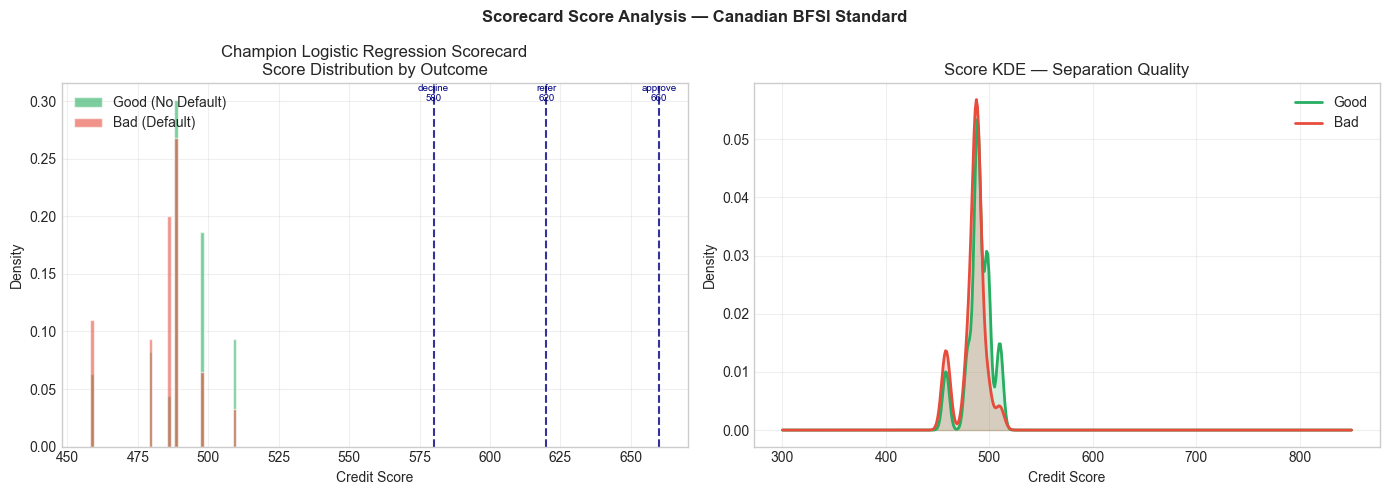

In [4]:
dist_analysis = score_distribution_analysis(scores, y_test, config["scorecard"]["decision_thresholds"])

print("\nScore Band Analysis:")
print(dist_analysis["score_bands"].to_string(index=False))
print(f"\nMean score: {dist_analysis['mean_score']:.0f}")
print(f"Std score:  {dist_analysis['std_score']:.0f}")
print(f"P5 / P95:   {dist_analysis['p5_score']:.0f} / {dist_analysis['p95_score']:.0f}")

fig = plot_score_distribution(scores, y_test, config["scorecard"]["decision_thresholds"],
                               title="Champion Logistic Regression Scorecard")
plt.savefig("../reports/output/03_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Scorecard Points Table


Scorecard Points Table (sample):
Feature                                 Bin    N  EventRate     WoE  Coefficient  Points
 DELINQ                                 0.0 3255      10.94 -0.7058      0.00000   162.0
 DELINQ                                 1.0  426      38.03  0.9030      0.00000   162.0
 DELINQ                                 2.0  247      56.68  1.6602      0.00000   162.0
 DELINQ                                 3.0  163      56.44  1.6505      0.00000   162.0
 DELINQ                                 4.0   81     100.00 20.6977      0.00000   162.0
  DEROG                                 0.0 3462      14.01 -0.4231      0.00000   162.0
  DEROG                                 1.0  371      41.78  1.0595      0.00000   162.0
  DEROG                                 2.0  168      50.00  1.3914      0.00000   162.0
  DEROG                                 3.0  127      49.61  1.3756      0.00000   162.0
  DEROG                                 4.0   44     100.00 20.0874      0.0

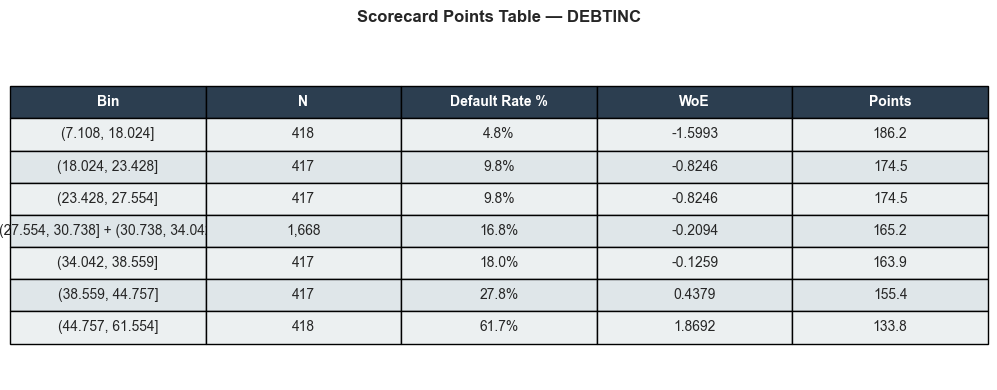

In [5]:
scorecard_df = scorecard.build_scorecard_table(woe_transformer)
print("\nScorecard Points Table (sample):")
print(scorecard_df.head(20).to_string(index=False))

# Visualise top feature
top_feature = scorecard_df.groupby("Feature")["Points"].std().idxmax()
fig = plot_scorecard_table(scorecard_df, top_feature)
plt.savefig(f"../reports/output/03_scorecard_points_{top_feature}.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Calibration Validation


Hostmer-Lemeshow Test:
  Statistic: 2.9756
  p-value:   0.9359
  Result:    Well-calibrated


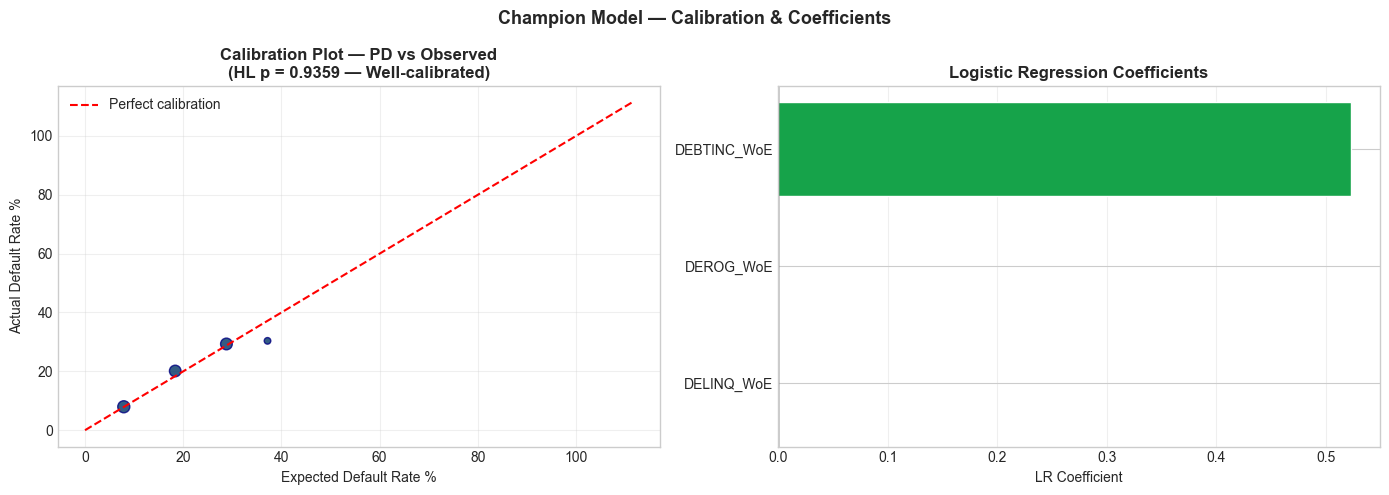

In [6]:
hl = hosmer_lemeshow_test(y_test.values, pd_test)
print(f"\nHostmer-Lemeshow Test:")
print(f"  Statistic: {hl['hl_statistic']:.4f}")
print(f"  p-value:   {hl['p_value']:.4f}")
print(f"  Result:    {hl['interpretation']}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Reliability diagram
decile_tbl = hl["decile_table"]
axes[0].scatter(decile_tbl["Expected_Bad"]/decile_tbl["N"]*100,
                decile_tbl["Observed_Bad"]/decile_tbl["N"]*100,
                s=decile_tbl["N"]/5, color="#003366", alpha=0.8, edgecolors="navy")
max_v = max(decile_tbl["Expected_Bad"].max(), decile_tbl["Observed_Bad"].max()) / decile_tbl["N"].min() * 100 * 1.2
axes[0].plot([0, max_v], [0, max_v], "r--", lw=1.5, label="Perfect calibration")
axes[0].set_xlabel("Expected Default Rate %"); axes[0].set_ylabel("Actual Default Rate %")
axes[0].set_title(f"Calibration Plot — PD vs Observed\n(HL p = {hl['p_value']:.4f} — {hl['interpretation']})",
                   fontweight="bold")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Coefficient chart
coefs = pd.DataFrame({
    "Feature":     X_train_woe.columns,
    "Coefficient": scorecard.lr.coef_[0]
}).sort_values("Coefficient", key=abs, ascending=True)
colors = ["#dc2626" if c < 0 else "#16a34a" for c in coefs["Coefficient"]]
axes[1].barh(coefs["Feature"], coefs["Coefficient"], color=colors, edgecolor="white")
axes[1].axvline(0, color="black", lw=1)
axes[1].set_xlabel("LR Coefficient"); axes[1].set_title("Logistic Regression Coefficients", fontweight="bold")
axes[1].grid(axis="x", alpha=0.3)

plt.suptitle("Champion Model — Calibration & Coefficients", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/output/03_calibration_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Save Champion Model

In [7]:
scorecard_df.to_csv("../data/processed/scorecard_points.csv", index=False)
joblib.dump(scorecard, "../models/scorecard_model.pkl")
print(f"\n Champion scorecard saved: models/scorecard_model.pkl")
print(f"   Scorecard points saved:   data/processed/scorecard_points.csv")
print(f"\nModel summary:")
print(f"  Score range:   {scores.min()}–{scores.max()}")
print(f"  Test AUC:      {metrics['AUC_ROC']:.4f}")
print(f"  Test Gini:     {metrics['Gini']:.4f}")
print(f"  Test KS:       {metrics['KS_Statistic']:.4f}")


 Champion scorecard saved: models/scorecard_model.pkl
   Scorecard points saved:   data/processed/scorecard_points.csv

Model summary:
  Score range:   458–510
  Test AUC:      0.6681
  Test Gini:     0.3363
  Test KS:       0.2810
